# Part II — Number of Paths vs. Number of Basis Functions in American Option Pricing

## Reproduction of Glasserman & Yu (2004)

**Article:** P. Glasserman and B. Yu, *"Number of Paths versus Number of Basis Functions in American Option Pricing"*, The Annals of Applied Probability, 2004, Vol. 14, No. 4, pp. 2090–2119.

The objective is to reproduce the main numerical experiment (Table 1) of the paper, which demonstrates that in simulation-based American option pricing using polynomial basis functions, the number of Monte Carlo paths $N$ must grow *exponentially* in the number of basis functions $K$ to ensure worst-case convergence.

For Brownian motion with Hermite polynomial basis functions, the critical threshold is $K_{\mathrm{crit}} = \log N / c_\rho$ where $c_\rho = 2\log(2+\sqrt{\rho})$ and $\rho = t_2/t_1$.

**Structure of this notebook:**
1. Setup and parameters
2. Mathematical building blocks (Hermite polynomials, basis functions)
3. Brownian motion simulation
4. Monte Carlo MSE estimation (with GPU acceleration)
5. Reproduction of Table 1
6. Verification of key theoretical predictions (Lemma 1, $1/N$ proportionality)
7. Visualisation of the exponential moment growth
8. Comparison of Brownian vs. Geometric Brownian motion thresholds

## 1. Setup and Parameters

We use GPU acceleration via CuPy for efficient simulation. The parameters match those in Table 1 of the paper.

In [1]:
!nvcc --version # for colab

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [2]:
!pip install cupy-cuda12x # for colab

In [3]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import pandas as pd
import scipy.special # for Hermite polynomials

In [4]:
t1 = 1
t2 = 2
rho = 2
c_rho = 2* np.log(2 + np.sqrt(rho))
K_values = np.arange(1, 13, step=1)
N_values = [500 * (2**i) for i in range(9)]
B = 5000
seed = 42

In [24]:
_factorials_cache = {}

def get_factorials(K_max):
    if K_max not in _factorials_cache:
        k_array = np.arange(K_max + 1)
        fact_cpu = scipy.special.factorial(k_array, exact=False)
        _factorials_cache[K_max] = cp.array(np.sqrt(fact_cpu))
    return _factorials_cache[K_max]

## 2. Hermite Polynomials and Basis Functions

The probabilistic Hermite polynomials are defined by the three-term recurrence:

$$\mathrm{He}_0(x) = 1, \quad \mathrm{He}_1(x) = x, \quad \mathrm{He}_{n+1}(x) = x\,\mathrm{He}_n(x) - n\,\mathrm{He}_{n-1}(x)$$

The normalised basis functions used in the paper are:

$$\psi_{nk}(x) = \frac{1}{\sqrt{k!}}\,\mathrm{He}_k\!\left(\frac{x}{\sqrt{t_n}}\right)$$


In [25]:
def hermite_polynomial(x_array, K_max):

    N = len(x_array)
    H = cp.zeros((N, K_max + 1))
    H[:, 0] = 1.0
    H[:, 1] = x_array
    for k in range(1, K_max):
        H[:, k+1] = x_array*H[:, k] - k*H[:, k-1]

    return H

def psi(x_array, t, K_max):

    H = hermite_polynomial(x_array / cp.sqrt(t), K_max)
    sqrt_factorials = get_factorials(K_max)

    return H / sqrt_factorials

##3. Simulation of Brownian Motions

We simulate correlated pairs $(S_1, S_2)$ using the increment structure of Brownian motion:

$$S_1 = \sqrt{t_1}\,Z_1, \quad S_2 = S_1 + \sqrt{t_2 - t_1}\,Z_2, \quad Z_1, Z_2 \overset{\mathrm{iid}}{\sim} \mathcal{N}(0,1)$$



In [26]:
def simulate_brownian(N, t1, t2, seed=None):

    if seed is not None:
        cp.random.seed(seed)

    S1 = cp.random.normal(0, cp.sqrt(t1), N)
    increment = cp.random.normal(0, cp.sqrt(t2 - t1), N)
    S2 = S1 + increment

    return S1, S2

## 4. MSE Estimation

### 4.1 Single-batch estimator

### 4.2 Batched computation

We repeat this $B = 5000$ times and average the squared errors to estimate $\mathrm{MSE}(\tilde{\beta})$.

The computation is vectorised over batches using `cp.einsum` for GPU efficiency, with chunked processing to avoid out-of-memory errors.

In [8]:
def compute_mse_one_batch(N, K, t1, t2, rho):
    S1, S2 = simulate_brownian(N, t1, t2)

    # Y : length : (N,)
    Y = rho**(K/2) * psi(S2, t2, K)[:, K]
    Psi_1 = psi(S1, t1, K)
    gamma = Psi_1.T @ Y / N
    beta_true = np.zeros(K + 1)
    beta_true[K] = 1.0

    return np.sum((gamma - beta_true)**2)

In [27]:
def compute_mse_all_batches(N_sim, K, B, t1, t2, rho, batch_size=100):
    total = 0.0
    n_chunks = B // batch_size

    for _ in range(n_chunks):

        S1 = cp.random.normal(0, cp.sqrt(t1), (batch_size, N_sim))
        increment = cp.random.normal(0, cp.sqrt(t2 - t1), (batch_size, N_sim))
        S2 = S1 + increment

        S2_flat = S2.reshape(-1)
        Psi2 = psi(S2_flat, t2, K).reshape(batch_size, N_sim, K + 1)
        Y = rho**(K / 2) * Psi2[:, :, K]

        S1_flat = S1.reshape(-1)
        Psi1 = psi(S1_flat, t1, K).reshape(batch_size, N_sim, K + 1)


        gamma = cp.einsum('bni, bn -> bi', Psi1, Y) / N_sim


        beta_true = cp.zeros(K + 1)
        beta_true[K] = 1.0

        errors = cp.sum((gamma - beta_true)**2, axis=1)
        total += float(cp.sum(errors))

        del S1, S2, S1_flat, S2_flat, Psi1, Psi2, Y, gamma, errors
        cp.get_default_memory_pool().free_all_blocks()

    return total / B

Main estimation function

In [10]:
def estimate_mse(K, N, B, t1, t2, rho, K_threshold=7):
    N_large = 500000

    if K < K_threshold:
        batch_size = 500  # N petit → on peut se permettre grand batch_size
        mse = compute_mse_all_batches(N, K, B, t1, t2, rho, batch_size)
    else:
        batch_size = 10   # N_large énorme → petit batch_size
        mse = compute_mse_all_batches(N_large, K, B, t1, t2, rho, batch_size)
        mse = mse * N_large / N

    return mse


## 5. Reproduction of Table 1

We now run the full grid of $(N, K)$ combinations. This is the most computationally intensive step.

**Expected runtime:** approximately 71 minutes on a Colab T4 GPU, depending on load.

In [12]:
import time

results = np.full((len(K_values), len(N_values)), np.nan)
start_total = time.time()

for i, K in enumerate(K_values):
    for j, N in enumerate(N_values):
        results[i, j] = estimate_mse(K, N, B=5000, t1=t1, t2=t2, rho=rho)
        print(f"K={K}, N={N} → MSE ≈ {results[i,j]:.4f}")

elapsed = time.time() - start_total
print(f"\nTemps total : {elapsed/60:.1f} minutes")

K=1, N=500 → MSE ≈ 0.0098
K=1, N=1000 → MSE ≈ 0.0050
K=1, N=2000 → MSE ≈ 0.0025
K=1, N=4000 → MSE ≈ 0.0012
K=1, N=8000 → MSE ≈ 0.0006
K=1, N=16000 → MSE ≈ 0.0003
K=1, N=32000 → MSE ≈ 0.0002
K=1, N=64000 → MSE ≈ 0.0001
K=1, N=128000 → MSE ≈ 0.0000
K=2, N=500 → MSE ≈ 0.0838
K=2, N=1000 → MSE ≈ 0.0425
K=2, N=2000 → MSE ≈ 0.0206
K=2, N=4000 → MSE ≈ 0.0101
K=2, N=8000 → MSE ≈ 0.0051
K=2, N=16000 → MSE ≈ 0.0026
K=2, N=32000 → MSE ≈ 0.0013
K=2, N=64000 → MSE ≈ 0.0006
K=2, N=128000 → MSE ≈ 0.0003
K=3, N=500 → MSE ≈ 0.6519
K=3, N=1000 → MSE ≈ 0.3250
K=3, N=2000 → MSE ≈ 0.1713
K=3, N=4000 → MSE ≈ 0.0849
K=3, N=8000 → MSE ≈ 0.0425
K=3, N=16000 → MSE ≈ 0.0210
K=3, N=32000 → MSE ≈ 0.0105
K=3, N=64000 → MSE ≈ 0.0052
K=3, N=128000 → MSE ≈ 0.0027
K=4, N=500 → MSE ≈ 4.9657
K=4, N=1000 → MSE ≈ 3.0200
K=4, N=2000 → MSE ≈ 1.6018
K=4, N=4000 → MSE ≈ 0.7889
K=4, N=8000 → MSE ≈ 0.3394
K=4, N=16000 → MSE ≈ 0.1788
K=4, N=32000 → MSE ≈ 0.0961
K=4, N=64000 → MSE ≈ 0.0456
K=4, N=128000 → MSE ≈ 0.0232
K=5, N=500 →

## 6. Results and Visualisation

### 6.1 Table 1 — MSE across (N, K) combinations


Table 1 — Estimates of MSE(β̃) for various combinations of K basis functions and N paths
The critical values K = log(N)/c_ρ are displayed in the bottom row

            500    1000    2000       4000    8000   16000  32000  64000 128000
K=1        0.01    0.01    0.00       0.00    0.00    0.00   0.00   0.00   0.00
K=2        0.08    0.04    0.02       0.01    0.01    0.00   0.00   0.00   0.00
K=3        0.65    0.33    0.17       0.08    0.04    0.02   0.01   0.01   0.00
K=4         5.0     3.0     1.6       0.79    0.34    0.18   0.10   0.05   0.02
K=5          35      20      15        7.4     5.0     1.4    1.0   0.49   0.20
K=6         197     176      91         31      22      17    8.0    4.0    1.9
K=7        3330    2415    1060        702     199      92     92     42     19
K=8       47931   17851   10696       3955    3598    1239    310    178    111
K=9       82255   93648  184775      19477   68588    3254   2986   2484   1292
K=10    1073964  163556  149342     103228 

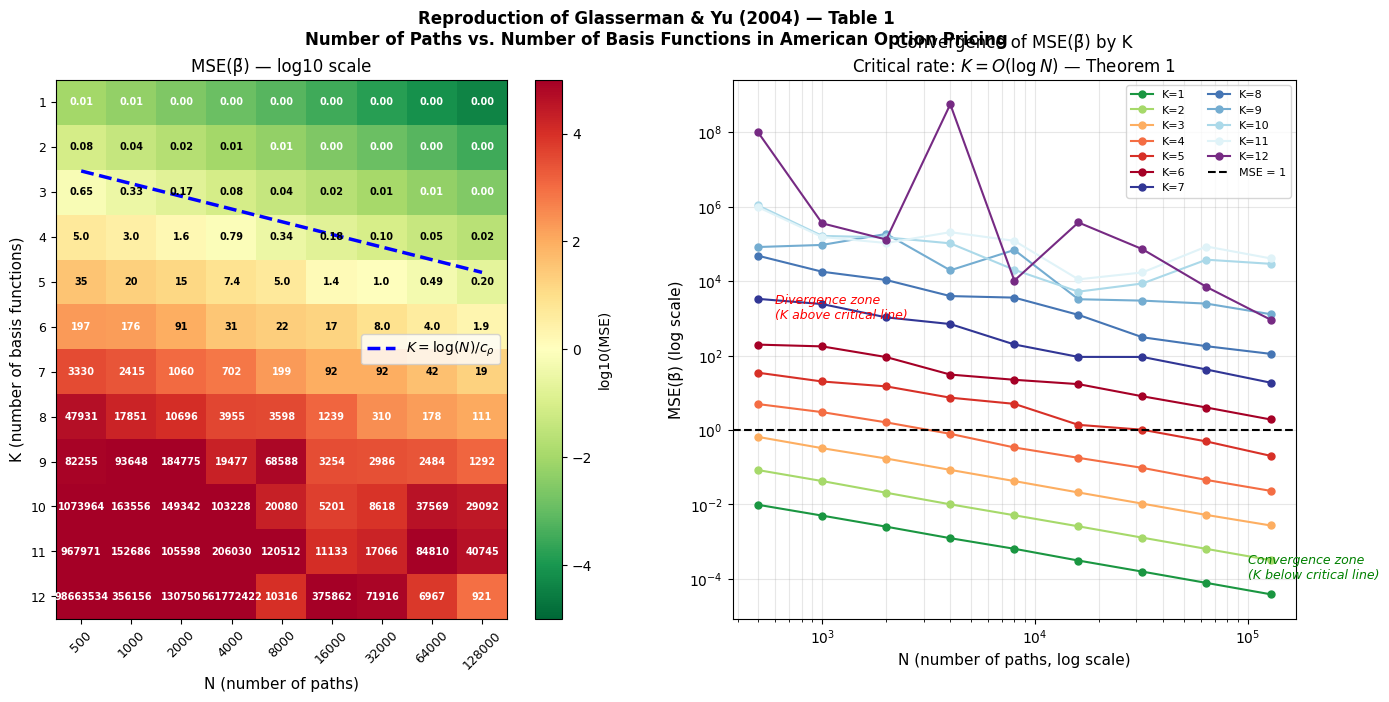

In [29]:
critical_K = [np.log(N) / c_rho for N in N_values]

df = pd.DataFrame(
    results,
    index=[f"K={k}" for k in K_values],
    columns=[str(n) for n in N_values]
)
df.loc["Bound"] = [f"{k:.1f}" for k in critical_K]


def format_mse(val):
    if np.isnan(val):
        return ""
    if val < 0.01:
        return f"{val:.2f}"
    if val < 1:
        return f"{val:.2f}"
    if val < 10:
        return f"{val:.1f}"
    return f"{val:.0f}"

df_formatted = df.copy()
for col in df.columns:
    df_formatted[col] = df[col].apply(
        lambda x: format_mse(float(x)) if x != "" else ""
    )

print("Table 1 — Estimates of MSE(β̃) for various combinations of K basis functions and N paths")
print("The critical values K = log(N)/c_ρ are displayed in the bottom row\n")
print(df_formatted.to_string())


fig, axes = plt.subplots(1, 2, figsize=(16, 7))



ax = axes[0]
results_display = np.where(np.isnan(results), np.nan, results)
log_results = np.log10(results_display + 1e-6)

im = ax.imshow(
    log_results,
    aspect='auto',
    cmap='RdYlGn_r',
    origin='upper',
    vmin=-5,
    vmax=5
)

# Axes
ax.set_xticks(range(len(N_values)))
ax.set_xticklabels([str(n) for n in N_values], rotation=45, fontsize=9)
ax.set_yticks(range(len(K_values)))
ax.set_yticklabels([str(k) for k in K_values], fontsize=9)
ax.set_xlabel("N (number of paths)", fontsize=11)
ax.set_ylabel("K (number of basis functions)", fontsize=11)
ax.set_title("MSE(β̃) — log10 scale", fontsize=12)
plt.colorbar(im, ax=ax, label="log10(MSE)")

for i in range(len(K_values)):
    for j in range(len(N_values)):
        val = results[i, j]
        if not np.isnan(val):
            text = format_mse(val)
            color = 'white' if abs(log_results[i, j]) > 2 else 'black'
            ax.text(j, i, text, ha='center', va='center',
                   fontsize=7, color=color, fontweight='bold')

# K = log(N) / c_rho
critical_y = [np.log(N) / c_rho - 1 for N in N_values]
ax.plot(
    range(len(N_values)),
    critical_y,
    color='blue',
    linewidth=2.5,
    linestyle='--',
    label=r"$K = \log(N)/c_\rho$"
)
ax.legend(fontsize=10)

#MSE vs N
ax2 = axes[1]

colors = [
    '#1a9641',
    '#a6d96a',
    '#fdae61',
    '#f46d43',
    '#d73027',
    '#a50026',
    '#313695',
    '#4575b4',
    '#74add1',
    '#abd9e9',
    '#e0f3f8',
    '#762a83',
]

for i, K in enumerate(K_values):

    y_vals = results[i, :]
    mask = ~np.isnan(y_vals)
    if mask.sum() > 0:
        ax2.plot(
            np.array(N_values)[mask],
            y_vals[mask],
            marker='o',
            markersize=5,
            linewidth=1.5,
            color=colors[i],
            label=f"K={K}"
        )

ax2.axhline(
    y=1.0,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label="MSE = 1"
)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel("N (number of paths, log scale)", fontsize=11)
ax2.set_ylabel("MSE(β̃) (log scale)", fontsize=11)
ax2.set_title(
    "Convergence of MSE(β̃) by K\n"
    r"Critical rate: $K = O(\log N)$ — Theorem 1",
    fontsize=12
)
ax2.legend(fontsize=8, ncol=2, loc='upper right')
ax2.grid(True, alpha=0.3, which='both')


ax2.annotate(
    'Convergence zone\n(K below critical line)',
    xy=(100000, 0.0001),
    fontsize=9,
    color='green',
    style='italic'
)
ax2.annotate(
    'Divergence zone\n(K above critical line)',
    xy=(600, 1000),
    fontsize=9,
    color='red',
    style='italic'
)

# Title
plt.suptitle(
    "Reproduction of Glasserman & Yu (2004) — Table 1\n"
    "Number of Paths vs. Number of Basis Functions in American Option Pricing",
    fontsize=12,
    fontweight='bold'
)

plt.show()


### 6.2 Verification: MSE is proportional to $1/N$

A key assumption underlying the extrapolation trick is that $\mathrm{MSE}(\tilde{\beta}) \propto 1/N$ exactly. We verify this by plotting $\mathrm{MSE} \times N$ (normalised) against $N$. If the proportionality holds, each curve should be perfectly flat at 1.0.

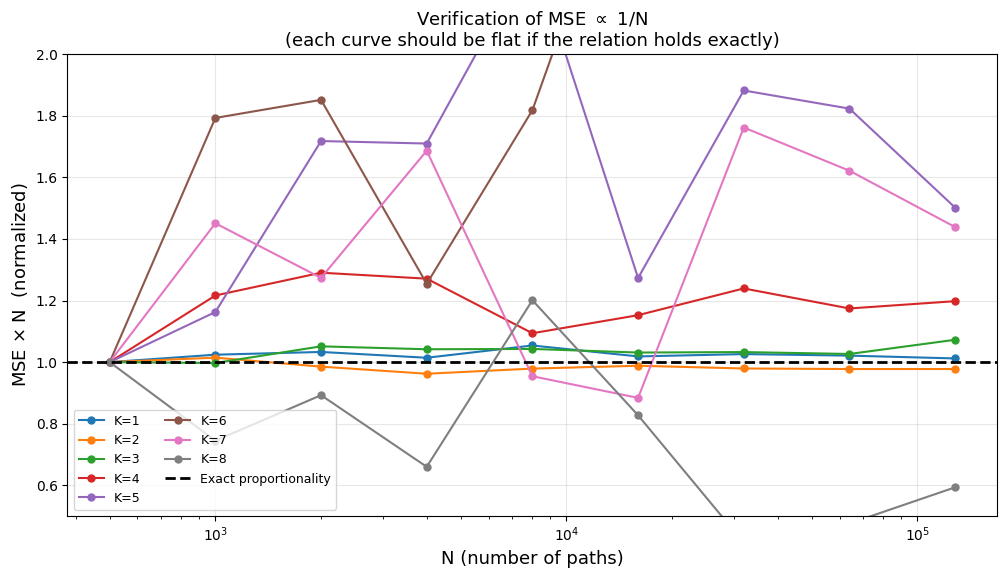

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))

for i, K in enumerate(K_values[:8]):  # K=1 to K=8
    mse_times_N = results[i, :] * np.array(N_values)
    if mse_times_N[0] > 0:
        normalized = mse_times_N / mse_times_N[0]
        ax.plot(N_values, normalized, 'o-', label=f'K={K}', markersize=5)


ax.axhline(y=1.0, color='black', linestyle='--', linewidth=2,
           label='Exact proportionality')
ax.set_xscale('log')
ax.set_xlabel('N (number of paths)', fontsize=13)
ax.set_ylabel(r'MSE $\times$ N  (normalized)', fontsize=13)
ax.set_title(
    r'Verification of MSE $\propto$ 1/N' + '\n'
    r'(each curve should be flat if the relation holds exactly)',
    fontsize=13
)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 2.0])



plt.show()

### 6.3 Why the MSE explodes: exponential growth of 4th-order moments

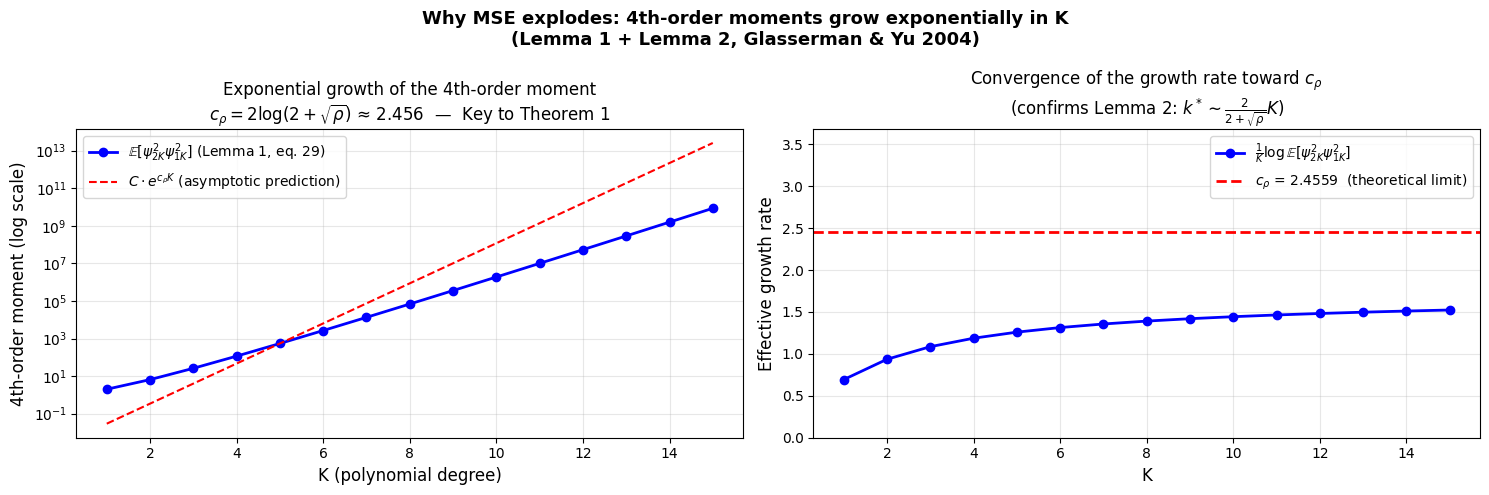

In [31]:
from scipy.special import comb

def lemma1_theoretical(k1, k2, rho):
    """
    Exact formula from Lemma 1, equation (29) of the paper:
    E[psi_{2,k2}^2(S2) * psi_{1,k1}^2(S1)]
    = sum_{k=0}^{min(k1,k2)} rho^{-k} * C(2k,k) * C(k1,k) * C(k2,k)
    """
    k_max = min(k1, k2)
    total = 0.0
    for k in range(k_max + 1):
        total += (
            (rho ** (-k))
            * comb(2*k, k, exact=True)
            * comb(k1, k, exact=True)
            * comb(k2, k, exact=True)
        )
    return float(total)

K_range = np.arange(1, 16)
moments_theo = np.array([lemma1_theoretical(K, K, rho) for K in K_range])
exp_prediction = np.exp(c_rho * K_range)

# Align the two curves at K=5
scale_factor = moments_theo[4] / exp_prediction[4]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#Moment in semi-log scale
ax1 = axes[0]
ax1.semilogy(
    K_range, moments_theo,
    'bo-', markersize=6, linewidth=2,
    label=r'$\mathbb{E}[\psi_{2K}^2 \psi_{1K}^2]$ (Lemma 1, eq. 29)'
)
ax1.semilogy(
    K_range, exp_prediction * scale_factor,
    'r--', linewidth=1.5,
    label=r'$C \cdot e^{c_\rho K}$ (asymptotic prediction)'
)
ax1.set_xlabel('K (polynomial degree)', fontsize=12)
ax1.set_ylabel('4th-order moment (log scale)', fontsize=12)
ax1.set_title(
    'Exponential growth of the 4th-order moment\n'
    r'$c_\rho = 2\log(2+\sqrt{\rho})$' + f' ≈ {c_rho:.3f}  —  '
    r'Key to Theorem 1',
    fontsize=12
)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

#Effective growth rate

ax2 = axes[1]
effective_rate = np.log(moments_theo) / K_range
ax2.plot(
    K_range, effective_rate,
    'bo-', markersize=6, linewidth=2,
    label=r'$\frac{1}{K}\log\mathbb{E}[\psi_{2K}^2 \psi_{1K}^2]$'
)
ax2.axhline(
    y=c_rho,
    color='red', linestyle='--', linewidth=2,
    label=f'$c_\\rho$ = {c_rho:.4f}  (theoretical limit)'
)
ax2.set_xlabel('K', fontsize=12)
ax2.set_ylabel('Effective growth rate', fontsize=12)
ax2.set_title(
    r'Convergence of the growth rate toward $c_\rho$' + '\n'
    r'(confirms Lemma 2: $k^* \sim \frac{2}{2+\sqrt{\rho}} K$)',
    fontsize=12
)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, c_rho * 1.5])

plt.suptitle(
    'Why MSE explodes: 4th-order moments grow exponentially in K\n'
    '(Lemma 1 + Lemma 2, Glasserman & Yu 2004)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('exponential_growth_moments.png', dpi=150, bbox_inches='tight')
plt.show()


Brownian vs Lognormal — Critical thresholds (Theorems 1 & 2)

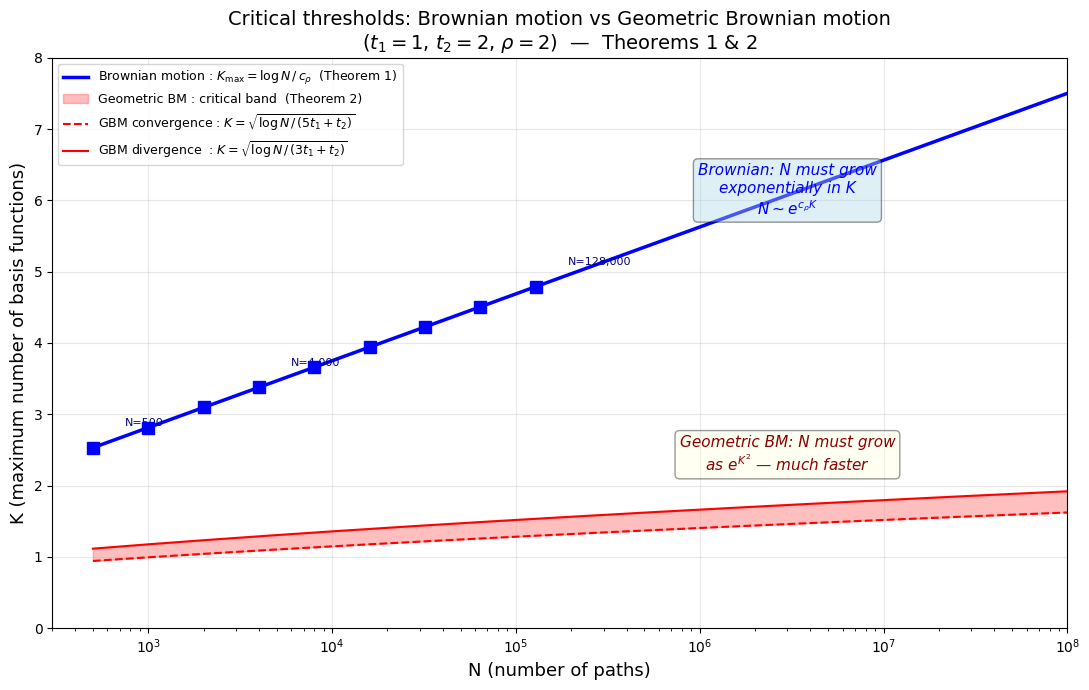

In [23]:

fig, ax = plt.subplots(figsize=(11, 7))

N_range_plot = np.logspace(np.log10(500), np.log10(1e8), 300)

# Brownian case (Theorem 1) : K_crit = log(N) / c_rho
K_crit_normal = np.log(N_range_plot) / c_rho

# Geometric Brownian case (Theorem 2)
# Convergence zone  : K = sqrt(log(N) / (5*t1 + t2))
# Divergence zone   : K = sqrt(log(N) / (3*t1 + t2))
K_crit_gbm_upper = np.sqrt(np.log(N_range_plot) / (5*t1 + t2))
K_crit_gbm_lower = np.sqrt(np.log(N_range_plot) / (3*t1 + t2))

# Brownian critical line
ax.semilogx(
    N_range_plot, K_crit_normal,
    'b-', linewidth=2.5,
    label=r'Brownian motion : $K_{\max} = \log N \,/\, c_\rho$  (Theorem 1)'
)

# GBM band
ax.fill_between(
    N_range_plot, K_crit_gbm_upper, K_crit_gbm_lower,
    alpha=0.25, color='red',
    label=r'Geometric BM : critical band  (Theorem 2)'
)
ax.semilogx(
    N_range_plot, K_crit_gbm_upper,
    'r--', linewidth=1.5,
    label=r'GBM convergence : $K = \sqrt{\log N \,/\, (5t_1+t_2)}$'
)
ax.semilogx(
    N_range_plot, K_crit_gbm_lower,
    'r-', linewidth=1.5,
    label=r'GBM divergence  : $K = \sqrt{\log N \,/\, (3t_1+t_2)}$'
)

# Annotations
ax.annotate(
    'Brownian: N must grow\nexponentially in K\n' + r'$N \sim e^{c_\rho K}$',
    xy=(3e6, 5.8),
    fontsize=11, color='blue',
    ha='center', fontstyle='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.4)
)
ax.annotate(
    'Geometric BM: N must grow\n' + r'as $e^{K^2}$ — much faster',
    xy=(3e6, 2.2),
    fontsize=11, color='darkred',
    ha='center', fontstyle='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.4)
)

# Points from Table 1 (our simulated results)
for N_pt in N_values:
    K_pt = np.log(N_pt) / c_rho
    ax.plot(N_pt, K_pt, 'bs', markersize=8, zorder=5)

# Labels for a few Table 1 points
for N_pt in [500, 4000, 128000]:
    K_pt = np.log(N_pt) / c_rho
    ax.annotate(
        f'N={N_pt:,}',
        xy=(N_pt, K_pt),
        xytext=(N_pt * 1.5, K_pt + 0.3),
        fontsize=8, color='navy'
    )

ax.set_xlabel('N (number of paths)', fontsize=13)
ax.set_ylabel('K (maximum number of basis functions)', fontsize=13)
ax.set_title(
    'Critical thresholds: Brownian motion vs Geometric Brownian motion\n'
    f'($t_1={t1}$, $t_2={t2}$, $\\rho={rho}$)  —  Theorems 1 & 2',
    fontsize=14
)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 8])
ax.set_xlim([300, 1e8])

plt.tight_layout()
plt.savefig('critical_thresholds_BM_vs_GBM.png', dpi=150, bbox_inches='tight')
plt.show()
